In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_lfw_people
from sklearn.metrics import classification_report
from sklearn.model_selection import cross_validate, train_test_split, GridSearchCV
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

from time import time

# Face Recognition

In this challenge we will:

* Use PCA to **compress black & white (B&W) images of famous people**
* Use the compressed images as samples for a classification task

This time, unlike the previous K-means challenge:

Instead of applying unsupervised learning on a single image to find patterns **between pixels** and reduce the number of colors, we will work on a **dataset of multiple B&W images** and aim to:

- Find common patterns **across all images**
- Reduce the number of **"principal features"** that describe these images

More concretely, we will try to express each image in our dataset as a **linear combination of principal components** using PCA (in this context, you can think of principal components as "principal images").

To compress the images, **we will zero out the smallest (least important) principal components** and keep only the most important ones in the equation.  
Each "reduced linear combination" will represent a compressed image.

Fortunately, since we only remove the least important components, this lower-dimensional projection of the dataset will preserve the **maximum data variance** between images. This means we should still be able to recognize which person appears in each image.

## 1) Load Data

❓ Run the cell below to download a copy of the famous LFW dataset provided by `Sklearn`.

In [2]:
# Download the data, takes about 2 minutes
!curl https://d32aokrjazspmn.cloudfront.net/materials/face-data-recognition.zip > data.zip

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  191M  100  191M    0     0  3547k      0  0:00:55  0:00:55 --:--:-- 5311k 0:00:28  0:00:34 3410k


Once downloaded, the next cell will extract the downloaded file into a `data` folder. It should look like this:

```bash
data
└── lfw_home
    ├── joblib
    ├── lfw
    ├── pairs.txt
    ├── pairsDevTest.txt
    └── pairsDevTrain.txt
```

In [3]:
!unzip -q data.zip
!tree -L 2 data

data
└── lfw_home
    ├── joblib
    ├── lfw
    ├── pairs.txt
    ├── pairsDevTest.txt
    └── pairsDevTrain.txt

4 directories, 3 files


In [4]:
# Import fetch_lfw_people from sklearn.datasets
faces = fetch_lfw_people(data_home='data', min_faces_per_person=70, resize=0.4, funneled=False)

💡 The **faces** object contains:
- `faces.images`: Images as plottable matrices of **50 x 37 pixels**
- `faces.data`: Flattened version of shape **1850 x 1** *(50 x 37 = 1850)*
- `faces.target`: Numeric class index representing one of 7 classes

❓ Run the cells below to check some basic information about your data and inspect some images.

In [5]:
print(f"- Images shape: {faces.images.shape}")
print(f"- Data (flattened images) shape: {faces.data.shape}")
print(f"- Target shape: {faces.target.shape}")
print(f"- Number of classes: {np.unique(faces.target).shape}")
print(f"- Each class is a famous person: {', '.join(faces.target_names)}")

- Images shape: (1288, 50, 37)
- Data (flattened images) shape: (1288, 1850)
- Target shape: (1288,)
- Number of classes: (7,)
- Each class is a famous person: Ariel Sharon, Colin Powell, Donald Rumsfeld, George W Bush, Gerhard Schroeder, Hugo Chavez, Tony Blair


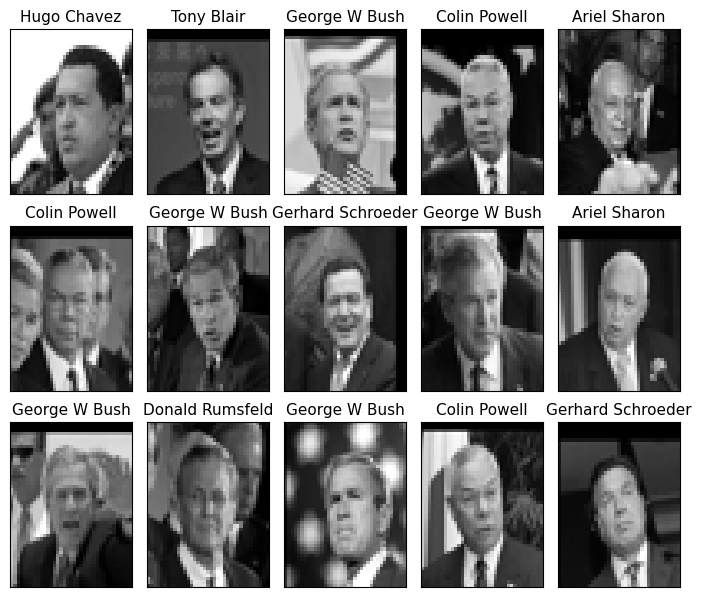

In [6]:
# Let's see some faces.
fig = plt.figure(figsize=(7,10))

for i in range(15):
    plt.subplot(5, 5, i + 1)
    plt.title(faces.target_names[faces.target[i]], size=11)
    plt.imshow(faces.images[i], cmap=plt.cm.gray)
    plt.xticks(())
    plt.yticks(())

plt.tight_layout()

**Disclaimer**: We are aware that this dataset lacks diversity and we apologize for that in advance. However, it is well-suited for understanding PCA (low pixel count, grayscale images, few categories, well-centered faces, etc.). Please continue with this challenge to understand the concept of "principal components"!

## 2) Compression with PCA

We have **1288** observations (images) and **1850** features (50 × 37 pixels).

Having this many features for so few observations is not ideal for Machine Learning; as a general rule, the following condition should hold:  
$n_{features} << \sqrt{n_{observations}}$.

**PCA** can help reduce the number of features to a more manageable size while preserving most of the information in the data.

❓ Fit a `PCA` on your **flattened images** and reduce the dimensions to **150 components**  
👉 Store the fitted `PCA` in a variable called **pca**  
👉 Then assign the transformation result to **data_projected**

In [7]:
from sklearn.decomposition import PCA

pca = PCA(n_components=150)
pca.fit(faces.data)

data_projected = pca.transform(faces.data)

The images were projected onto only the first **150 principal components**.

Here, a "component" refers to a **direction of maximum variance** in the data.

We no longer need **1850 pixels** to describe each image — just **150 values** are enough 🤓  

That's roughly a $\frac{1850}{150} = 12$x gain 🚀  

❓ Look at the **shape** of your components and make sure you understand what it represents  
❓ Look at the **shape** of the first component and think again about what it represents

In [8]:
print(pca.components_.shape)
print(pca.components_[0].shape)

(150, 1850)
(1850,)


The first component is a vector of 1850 values.  
We now have 150 components, each made up of 1850 values.

A face is defined as a linear combination of these components.

To see how this works, let's reconstruct an image from its reduced representation.

❓ Use `inverse_transform` on **data_projected** to reconstruct your compressed images  
👉 Store the result in **data_reconstructed**

In [9]:
data_reconstructed = pca.inverse_transform(data_projected)

❓ Plot the **13th image** (George W. Bush) from the reconstructed dataset and compare it with the original.

<details>
    <summary>💡 Hint</summary>
Reshape the flattened data into an image of **50 x 37 pixels**.
</details>

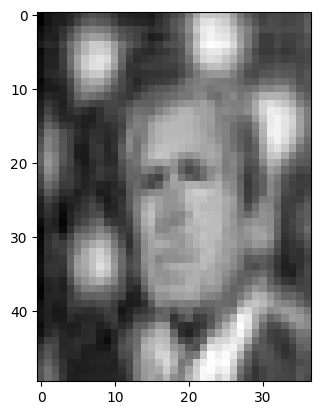

In [10]:
plt.imshow(data_reconstructed[12].reshape((50,37)), cmap=plt.cm.gray)

❓ Run the cell below to see a selection of reconstructed images.

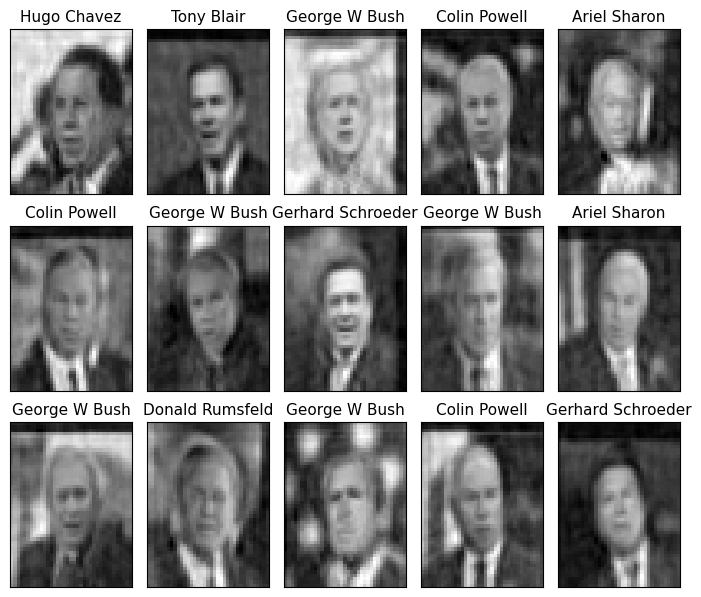

In [11]:
fig = plt.figure(figsize=(7, 10))

for i in range(15):
    plt.subplot(5, 5, i + 1)

    # Display each image with its label from the dataset.
    plt.title(faces.target_names[faces.target[i]], size=11)
    plt.imshow(pca.inverse_transform(data_projected)[i].reshape((50,37)), cmap=plt.cm.gray)

   # Remove axis ticks
    plt.xticks(())
    plt.yticks(())
    
plt.tight_layout()

### 🧪 Test Your Code

In [12]:
from nbresult import ChallengeResult

result = ChallengeResult('projection', shape=data_projected.shape)
result.write()
print(result.check())


============================= test session starts ==============================
platform darwin -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /Users/yaren/.pyenv/versions/workintech/bin/python
cachedir: .pytest_cache
rootdir: /Users/yaren/code/ds_projects/data-face-recoginition/tests
plugins: anyio-4.12.1, dash-4.0.0, typeguard-4.4.2
collecting ... collected 1 item

test_projection.py::TestProjection::test_shape PASSED                    [100%]

============================== 1 passed in 0.28s ===============================


💯 You can commit your code:

git add tests/projection.pickle

git commit -m 'Completed projection step'

git push origin master



## 3) Explore Your Principal Components

❓ Plot an image corresponding to the *"mean"* face of the entire dataset  
👉 Use the `gray` colormap for your plots in this section

<details>
    <summary>💡 Hint</summary>
    
You can use `pca.mean_` or `faces.data.mean(axis=0)`  
You will also need some **reshaping** to be able to plot it as an image
</details>

❓ Plot the images corresponding to the **first 5** principal components  

In [ ]:
# YOUR CODE HERE

☝️ Each PC is a flattened "image" of 1850 pixels.  
We just reshaped them so we could visualize them as normal images.

👇 Below are the definitions for these Principal Components  

❓ **Please read carefully and make sure you understand them**, otherwise consider opening a ticket 🎟️  

💡 Your first PCs are the most important **_directions_** in your observations, which have 1850 features

💡 They are the most important **_linear combinations_** of your 1850 pixels

💡 They are the components that **preserve the most _variance_** when your image dataset is projected onto these directions  

💡 The first few PCs represent the 2D pixel grid regions that contain the **most _variation_** across your 1288 images

❓ Plot the images corresponding to the **last 5** principal components.

In [ ]:
# YOUR CODE HERE

❓ Run the cell below to plot a few images corresponding to the principal components.

In [ ]:
n_rows, n_cols = 3, 5
fig, axs = plt.subplots(n_rows, n_cols, figsize=(16, 9))

for i in range(n_rows * n_cols):
    ax = axs[i // n_cols, i % n_cols]
    ax.set_title(f'PC {i * 10 + 1}', size=12)
    ax.set_xticks(()), ax.set_yticks(())
    ax.imshow(pca.components_[i * 10].reshape(50, 37), cmap='gray')

plt.tight_layout()

☝️ Take some time to look at the PCs and build your intuition for what they represent  

Notice how the first PCs capture the largest/simplest patterns that explain most of the variation between images:
- The orientation of the face: looking left, right, up or down
- The size of the face, mouth, nose and eyes

The last PCs capture the smallest/most detailed patterns:
- The shape of the mouth (open or closed)
- The jaw structure

Each image can be represented as the "mean face" plus a linear combination of 150 "PC faces".

If you want to go further, check out the optional **Reconstruction of an Original Image** section.

## 4) Choose the Optimal Number of Components

We are facing a classic **trade-off** in Machine Learning ⚖️

Using a **large number of components** gives a compressed image that:  
🙂 Is very close to the original in terms of image quality  
🙁 Is not much lighter than the original  

Using a **small number of components** gives a compressed image that:  
🙂 Is significantly lighter than the original  
🙁 Is far from the original in terms of image quality  

It is very important to find **how many components we need** to describe the data without losing too much information  

We can determine this visually by plotting the **cumulative sum of the explained variance ratio vs. the number of components**  

This information is stored in the `explained_variance_ratio_` attribute of a fitted `PCA` object from `sklearn`  

❓ Plot the **cumulative sum of the explained variance ratio vs. the number of components**

In [ ]:
# YOUR CODE HERE

☝️ This curve shows quantitatively how much of the total variance is captured by the first components.  

❓ Run the cell below and examine the plot to verify the following statements:  
- The **first component** alone is sufficient to explain **~20% of the variance**.
- The first **25 components** are sufficient to explain **75% of the variance**.
- Approximately **94 components** are needed to explain **90% of the variance**.

In [ ]:
plt.figure(figsize=(16, 9))

# Plot the data
plt.plot(range(1, pca.n_components_+1), np.cumsum(pca.explained_variance_ratio_))

# Set labels
plt.xlabel('number of components')
plt.ylabel('cumulative explained variance')

plt.grid()

# Set axis limits
plt.xlim((0, 151))
plt.ylim((0, 1))

# Add reference lines to the plot
plt.hlines(
    y=[.75, .9],
    xmin=[-5, -5],
    xmax=[25, 94],
    linestyles='dotted',
    colors=['red', 'orange'],
    linewidth=2
)
plt.vlines(
    x=[25, 94],
    ymin=[0, 0],
    ymax=[.75, .9],
    linestyles='dotted',
    colors=['red', 'orange'],
    linewidth=2
);

❓ What is the minimum number of components you need to retain in order to capture at least 80% of the variance?  
👉 Assign your answer to a variable called `minimal_pc_count`.

In [ ]:
# YOUR CODE HERE

### 🧪 Test Your Code

In [ ]:
from nbresult import ChallengeResult

result = ChallengeResult('components', min_pc = minimal_pc_count)
result.write()
print(result.check())

## 5) Classify Images (PCA as Feature Engineering)

Now it's time to use **PCA** for **supervised Machine Learning** 🚀

Here is the task 👇

Given a **face photo** from a set of famous people, the model should be able to tell **who the face belongs to**.

Translating this task into Machine Learning terms 👇
- **Samples**: Images (pictures)
- **Features**: Pixels of the images
- **Target**: One of multiple classes (7 classes)

❓ Cross-validate a model of your choice for the classification task  
👉 Record the time needed to train and evaluate the model

<details span='markdown'>
    <summary>💡 Hint</summary>
You can use the following approach to record execution time:    
```python
from time import time
start = time()
# CODE whose runtime you want to measure
execution_time = time() - start
```
</details>

In [ ]:
# YOUR CODE HERE

❓ Follow the same steps, this time using the projected images as features.

In [ ]:
# YOUR CODE HERE

👉 Compare your scores and execution times

Your model quality should have dropped slightly.
However, the time needed to "select" the model (train and evaluate it) should have decreased significantly!

From a business perspective, this is a big win 🏆  
As you will see in the ML Ops module, training models has a cost 💸🙈

## 6) Search for the Optimal Number of Components

*This time using a Machine Learning method: Grid Search*.

💡 Now that we have a supervised (feature-target) ML setup, we can find the optimal number of components using grid search.

❓ Before continuing, set aside 30% of your data as a test set  

👉 As usual, assign your split data to `X_train`, `X_test`, `y_train`, `y_test`  
👉 Use `random_state=42` inside `train_test_split` to compare results with your classmates

💡 We will **select** our model by performing **cross-validation** on the **training set**  
Then we will **evaluate** our model by **scoring** it on the **test set**

In [ ]:
# YOUR CODE HERE

💡 A pipeline is required for grid search  

❓ Use [`make_pipeline`](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.make_pipeline.html) to create a two-step pipeline:
- A `PCA` (no need to choose the number of components for now)
- An [`SVC`](https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html) algorithm as the estimator

In [ ]:
# YOUR CODE HERE

❓ Create a cross-validated grid search using your pipeline  

👉 Search only over the following number of components for `PCA`:  
`[50, 100, 200, 300]`

In [ ]:
# YOUR CODE HERE

❓ Print the [classification report](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html#sklearn.metrics.classification_report) of your best model  
👉 Use the **best estimator** from the grid search to generate predictions for **X_test**  
👉 Compare these predictions with **y_test** to print the classification report

In [ ]:
# YOUR CODE HERE

You may get an UndefinedMetricWarning if there are no correct predictions for one of the classes.

❓ What is the number of components that gives the best score?  
👉 Assign the value to a variable called **best_n_components**.

In [ ]:
# YOUR CODE HERE

### 🧪 Test Your Code

In [ ]:
from nbresult import ChallengeResult

result = ChallengeResult('search_components', best_pc=best_n_components)
result.write()
print(result.check())

## 7) What About Scaling, Balancing and Tuning?

*The full machine learning pipeline*

We spent a lot of time on PCA but there are **3 more ML techniques** you can use to improve your score:
- Scaling your data before applying PCA
- Using a balancing method since the classes are imbalanced
- Finding the best hyperparameters for your estimator using grid search

Let's apply these and see how using `PCA` together with the ML techniques we've seen so far helps us achieve a higher score.

❓ Cross-validate only with PCA + SVC to use as a baseline

In [ ]:
baseline = pd.Series(y).value_counts(normalize=True).max()

score_base = cross_validate(
    make_pipeline(
        PCA(n_components=best_n_components),
        SVC()
    ),
    X, y,
    scoring='accuracy',
    cv=3,
    n_jobs=-1
)['test_score'].mean()


print(f"""
    Accuracy scores:
    Baseline (frequency of most frequent class): {baseline: .2%}
    Base Model (PCA + SVC): {score_base:.2%}
""")

### Scaling

❓ Scale your data before dimensionality reduction with `PCA`  
👉 Create a pipeline with the following **3 steps**:
- Scaling with `StandardScaler`
- Dimensionality reduction with `PCA` (use the **best_n_components** value from your previous search)
- Prediction with `SVC` (keep all default parameters)

In [ ]:
# YOUR CODE HERE

❓ Evaluate your pipeline with **3-fold** cross-validation on all **X** and **y**  
👉 Save the mean score to the variable **score_scaling**  
👉 Check your new score

In [ ]:
# YOUR CODE HERE

☝️ Going up

### Balancing

❓ Check the distribution of your target classes

In [ ]:
# YOUR CODE HERE

☝️ As you can see, the classes are severely **imbalanced**

The most represented class appears in 41% of the images  
The least represented class appears in only 5.5% of the images  

This causes your model to over-predict the most represented class, leading to:
- Lower **precision** scores for the most represented classes  
- Lower **recall** scores for the least represented classes

❓ Train another pipeline that accounts for class imbalance  
👉 Check the [documentation](https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html) of the `SVC` estimator  
👉 Find and use the parameter that helps with class imbalance in `SVC`  
👉 Save the mean score to the variable **score_balanced** and check your new score

In [ ]:
# YOUR CODE HERE

🚀 No ceiling

### Fine-Tuning

❓ Fine-tune your model to find the hyperparameter combination that gives the best score  
👉 Search over at most 3 hyperparameters  
👉 Try at most 3 values for each  
👉 A sample search dictionary you can use is provided below:
```python
grid = {
        'svc__kernel': ['rbf', 'poly', 'sigmoid'],
        'svc__gamma': [1e-4, 1e-3, 1e-2],
        'svc__C': [10, 1e2, 1e3]
}
```
ℹ️ These hyperparameter ranges are for illustration purposes only and do not guarantee the best model combination. Feel free to change the values as you wish!

In [ ]:
grid = {
    'svc__kernel': ['rbf', 'poly', 'sigmoid'],
    'svc__gamma': [1e-4, 1e-3, 1e-2],
    'svc__C': [10, 1e2, 1e3]
}

search = GridSearchCV(
    pipe_balanced, 
    grid,
    cv=3,
    scoring='accuracy'
)

search.fit(X, y)
score_tuned = search.best_score_
round(score_tuned, 5)

🚀 We improved accuracy by 10 points compared to our baseline model  

A dimensionality reduction technique like `PCA` allows us to train, cross-validate and fine-tune our models faster  

The fine-tuning process can be extremely long; being able to speed it up by applying dimensionality reduction upfront is a major advantage

### 🧪 Test Your Code

In [ ]:
from nbresult import ChallengeResult

result = ChallengeResult(
    'full_pipeline',
    score_scaled=score_scaling,
    score_balanced=score_balanced,
    score_tuned=score_tuned
)

result.write()
print(result.check())

🏁 **Don't forget to push your notebook.**  

Complete the day's tasks and come back here if you have time 😉

<details>
  <summary markdown='span'>🍔 Things to think about</summary>

You can compare the PCA-preprocessed classification result with the non-preprocessed one and check:
1. Is it faster?
2. Is it better?
3. Does it help find the linear separation?
</details>

## 8) (Optional) Reconstruction of an Original Image

👉 Examine the cells below that reconstruct the image step by step without using `inverse_transform`.  

👉 We start by selecting a single image as an example.

In [ ]:
# Let's reconstruct the 13th image
image_original = faces.images[12];
image_compressed = data_projected[12];

plt.imshow(image_original, cmap='gray');

👉 We manually compute the sum of products:  $X\_reconstructed_{i} = \sum_{i=1}^{n\_components}{X_{projected_i} * W_i}$  
$W_i$ `represents the i-th principal component`

In [ ]:
# Start reconstruction from the mean of all images.
image_reconstructed = pca.mean_.copy(); 

# Then reconstruct the image by summing each of the 150 entries of its compressed representation, weighted by the corresponding principal components.
reconstruction = list()

for i in range(pca.n_components_):
    image_reconstructed += pca.components_[i] * image_compressed[i]
    reconstruction.append(image_reconstructed.copy())

👉 We place the reconstructed image next to the original.

In [ ]:
# Plot original and compressed image.
fig, ax = plt.subplots(1, 2, figsize = (5, 5))

# Original
ax[0].imshow(image_original, cmap='gray')
ax[0].set_title('Original Image')

# Reconstructed
ax[1].imshow(image_reconstructed.reshape(faces.images[0].shape), cmap='gray')
ax[1].set_title('Compressed reconstructed Image')

for ax in fig.axes:
    ax.axis('off')

plt.tight_layout()

👉 We plot the image at different stages of reconstruction.

In [ ]:
# Plot a few images at different stages of reconstruction
n_rows, n_cols = 3, 5
fig, axs = plt.subplots(n_rows, n_cols, figsize=(16, 9))
plt.suptitle('Image reconstructed using only...')

for i in range(n_rows * n_cols):
    ax = axs[i // n_cols, i % n_cols]
    ax.set_title(f'... {i * 10 + 1} PC', size=12)
    ax.set_xticks(()), ax.set_yticks(())
    ax.imshow(reconstruction[i * 10].reshape(50, 37), cmap='gray')

plt.tight_layout()